# Phishing Email Detection – Classical Machine Learning Models (TF-IDF + LR + SVM + RF + XGB)

This notebook trains and evaluates classical machine learning models using:

- TF-IDF feature extraction
- Logistic Regression (baseline)
- Linear SVM (strong linear classifier)
- Random Forest (non-linear ensemble classifierbased on decision trees)
- XGBoost

 Evaluated using:
- Accuracy
- Precision / Recall / F1
- Confusion Matrix

Models and vectorizer are saved to `../outputs/models/`.

In [2]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib
import matplotlib.pyplot as plt

## 1) Load Clean Dataset

In [3]:
DATA_PATH = Path("../data/processed/clean_emails.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Dataset shape: (29833, 4)
label
1    15447
0    14386
Name: count, dtype: int64


,text,label,source,clean_text
0,"hpl nom for may 25 , 2001 ( see attached file ...",0,enron,hpl nom for may see attached file hplno xls hp...
1,re : nom / actual vols for 24 th - - - - - - -...,0,enron,re nom actual vols for th forwarded by sabrae ...
2,"enron actuals for march 30 - april 1 , 201 est...",0,enron,enron actuals for march april estimated actual...
3,"hpl nom for june 1 , 2001 ( see attached file ...",0,enron,hpl nom for june see attached file hplno xls h...
4,# 9760 tried to get fancy with your address an...,0,enron,tried to get fancy with your address and it ca...


## 2) Train/Test Split (80/20, Stratified)

Stratified split keeps label proportions similar in train and test.

In [4]:
X = df["clean_text"].fillna(" ")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())

Train size: 23866
Test size: 5967

Train label counts:
 label
1    12357
0    11509
Name: count, dtype: int64

Test label counts:
 label
1    3090
0    2877
Name: count, dtype: int64


## 2.5) Data Leakage Check
Verify there are no duplicate emails shared between the train and test sets.

In [5]:
# Check duplicate emails between train and test
train_set = set(X_train.astype(str))
test_set = set(X_test.astype(str))

duplicates = train_set.intersection(test_set)

print("Duplicate emails between train and test:", len(duplicates))

Duplicate emails between train and test: 0


## 3) TF-IDF Feature Extraction

Convert text to numerical vectors suitable for ML models.

In [6]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)   # unigrams + bigrams (helps phishing phrases)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vector shape:", X_train_vec.shape)

Vector shape: (23866, 5000)


## 4) Logistic Regression (Baseline)

Logistic Regression is a linear classifier that computes a weighted combination of 
input features and passes it through a sigmoid function to produce a probability 
between 0 and 1. Emails with predicted probability ≥ 0.5 are classified as phishing.

*Key parameters:*
- max_iter=2000 — maximum iterations for convergence
- random_state=42 — reproducibility

In [7]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (LR):\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.983911513323278

Classification Report (LR):

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2877
           1       0.98      0.99      0.98      3090

    accuracy                           0.98      5967
   macro avg       0.98      0.98      0.98      5967
weighted avg       0.98      0.98      0.98      5967



## 5) Linear SVM 
Linear SVM identifies an optimal hyperplane that maximises the margin between 
phishing and legitimate email classes. A linear kernel is used due to the sparse, 
high-dimensional nature of TF-IDF feature vectors.

*Key parameters:*
- max_iter=2000 — maximum iterations for convergence
- random_state=42 — reproducibility

In [8]:
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_vec, y_train)

y_pred_svm = svm.predict(X_test_vec)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.9849170437405732

Classification Report (SVM):

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2877
           1       0.98      0.99      0.99      3090

    accuracy                           0.98      5967
   macro avg       0.98      0.98      0.98      5967
weighted avg       0.98      0.98      0.98      5967



## 6) Random Forest Classifier
Random Forest builds multiple decision trees on random subsets of the training data 
and aggregates predictions via majority voting. Each split is evaluated using Gini 
impurity. The balanced class weight ensures equal treatment of phishing and 
legitimate classes during training.

*Key parameters:*
- n_estimators=100 — number of trees
- class_weight="balanced" — handles class imbalance
- random_state=42 — reproducibility


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # useful if imbalance exists
)

rf.fit(X_train_vec, y_train)
y_pred_rf = rf.predict(X_test_vec)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (RF):\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9805597452656276

Classification Report (RF):

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2877
           1       0.98      0.98      0.98      3090

    accuracy                           0.98      5967
   macro avg       0.98      0.98      0.98      5967
weighted avg       0.98      0.98      0.98      5967



### 7)XGBoost (Extreme Gradient Boosting)


XGBoost builds decision trees sequentially, where each tree corrects the errors of 
the previous one. Unlike Random Forest (bagging), XGBoost uses boosting with a 
regularised objective function to prevent overfitting.

*Key parameters:*
- n_estimators=100 — number of boosting rounds
- learning_rate=0.1 — contribution of each tree
- max_depth=6 — tree depth
- scale_pos_weight — handles class imbalance
- random_state=42 — reproducibility

In [10]:
from xgboost import XGBClassifier
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos  # ratio of legitimate to phishing

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale,   # handles class imbalance
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_vec, y_train)
y_pred_xgb = xgb.predict(X_test_vec)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report (XGBoost):\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Legitimate", "Phishing"]))

XGBoost Accuracy: 0.9617898441427853

Classification Report (XGBoost):

              precision    recall  f1-score   support

  Legitimate       0.99      0.93      0.96      2877
    Phishing       0.94      0.99      0.96      3090

    accuracy                           0.96      5967
   macro avg       0.96      0.96      0.96      5967
weighted avg       0.96      0.96      0.96      5967



## 8) Confusion Matrices (LR + SVM + RF + XGB)

Confusion matrices show the count of:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This helps understand model behaviour beyond accuracy.

Saved: cm_phase1_logistic_regression.png


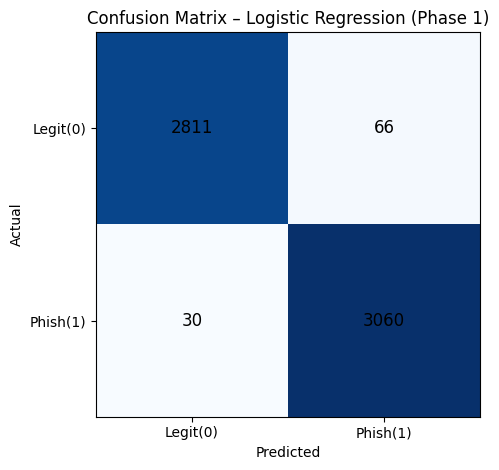

Saved: cm_phase1_linear_svm.png


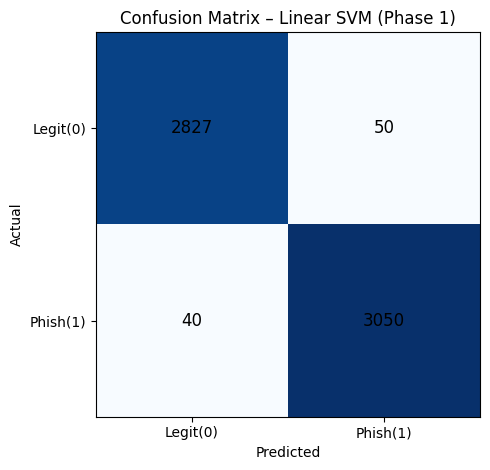

Saved: cm_phase1_random_forest.png


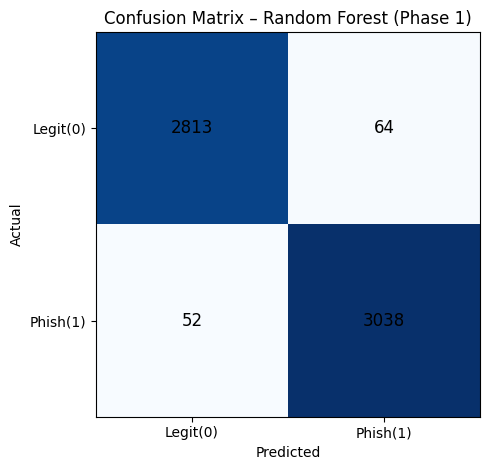

Saved: cm_phase1_xgboost.png


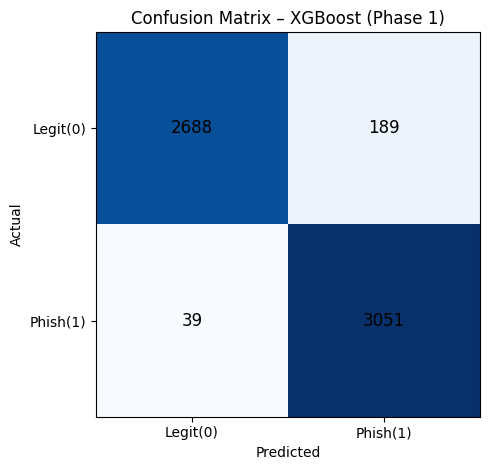

All Phase 1 confusion matrix plots saved.


In [35]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

def plot_conf_matrix(y_true, y_pred, title, filename=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Legit(0)", "Phish(1)"])
    plt.yticks([0, 1], ["Legit(0)", "Phish(1)"])
    for (i, j), val in zip([(0,0),(0,1),(1,0),(1,1)], cm.flatten()):
        plt.text(j, i, str(val), ha='center', va='center', fontsize=12)
    plt.tight_layout()
    if filename:
        plt.savefig(f'../outputs/figures/{filename}', dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
    plt.show()

plot_conf_matrix(y_test, y_pred_lr,  "Confusion Matrix – Logistic Regression (Phase 1)", "cm_phase1_logistic_regression.png")
plot_conf_matrix(y_test, y_pred_svm, "Confusion Matrix – Linear SVM (Phase 1)",          "cm_phase1_linear_svm.png")
plot_conf_matrix(y_test, y_pred_rf,  "Confusion Matrix – Random Forest (Phase 1)",        "cm_phase1_random_forest.png")
plot_conf_matrix(y_test, y_pred_xgb, "Confusion Matrix – XGBoost (Phase 1)",              "cm_phase1_xgboost.png")

print("All Phase 1 confusion matrix plots saved.")

In [36]:
from sklearn.metrics import confusion_matrix

print("LR Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nRF Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))



LR Confusion Matrix:
[[2811   66]
 [  30 3060]]

SVM Confusion Matrix:
[[2827   50]
 [  40 3050]]

RF Confusion Matrix:
[[2813   64]
 [  52 3038]]

XGBoost Confusion Matrix:
[[2688  189]
 [  39 3051]]


## 9) Save Models and Vectorizer

Saved to: `../outputs/models/`

In [13]:
MODELS_DIR = Path("../outputs/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(lr, MODELS_DIR / "logistic_regression.pkl")
joblib.dump(svm, MODELS_DIR / "linear_svm.pkl")
joblib.dump(rf, MODELS_DIR / "random_forest.pkl")
joblib.dump(xgb, MODELS_DIR / "xgboost.pkl")

print("✅ Saved models to:", MODELS_DIR)

✅ Saved models to: ..\outputs\models


## 10) Model Performance Comparison

To compare the effectiveness of different models, the evaluation results are summarised in a table.

The following models are compared:

- Logistic Regression (baseline)
- Support Vector Machine
- Random Forest
- XGBoost

The comparison focuses on the phishing class (label *1*), which is the most critical for security systems.

In [14]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision (Phish)": precision_score(y_test, y_pred_lr),
    "Recall (Phish)": recall_score(y_test, y_pred_lr),
    "F1 Score (Phish)": f1_score(y_test, y_pred_lr),
    "Macro F1": f1_score(y_test, y_pred_lr, average='macro')
})

# SVM
results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision (Phish)": precision_score(y_test, y_pred_svm),
    "Recall (Phish)": recall_score(y_test, y_pred_svm),
    "F1 Score (Phish)": f1_score(y_test, y_pred_svm),
    "Macro F1": f1_score(y_test, y_pred_svm, average='macro')
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision (Phish)": precision_score(y_test, y_pred_rf),
    "Recall (Phish)": recall_score(y_test, y_pred_rf),
    "F1 Score (Phish)": f1_score(y_test, y_pred_rf),
    "Macro F1": f1_score(y_test, y_pred_rf, average='macro')
})

#XGBoost
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision (Phish)": precision_score(y_test, y_pred_xgb),
    "Recall (Phish)": recall_score(y_test, y_pred_xgb),
    "F1 Score (Phish)": f1_score(y_test, y_pred_xgb),
    "Macro F1": f1_score(y_test, y_pred_xgb, average='macro')
})
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Phish),Recall (Phish),F1 Score (Phish),Macro F1
0,Logistic Regression,0.983912,0.978887,0.990291,0.984556,0.983883
1,Linear SVM,0.984917,0.983871,0.987055,0.985460,0.984896
2,Random Forest,0.980560,0.979368,0.983172,0.981266,0.980532
3,XGBoost,0.961790,0.941667,0.987379,0.963981,0.961648


In [15]:
from sklearn.metrics import accuracy_score

print("LR Train:", accuracy_score(y_train, lr.predict(X_train_vec)))
print("LR Test :", accuracy_score(y_test, lr.predict(X_test_vec)))

print("SVM Train:", accuracy_score(y_train, svm.predict(X_train_vec)))
print("SVM Test :", accuracy_score(y_test, svm.predict(X_test_vec)))

print("RF Train:", accuracy_score(y_train, rf.predict(X_train_vec)))
print("RF Test :", accuracy_score(y_test, rf.predict(X_test_vec)))

print("XGB Train:", accuracy_score(y_train, xgb.predict(X_train_vec)))
print("XGB Test :", accuracy_score(y_test, xgb.predict(X_test_vec)))

LR Train: 0.9893991452275204
LR Test : 0.983911513323278
SVM Train: 0.9978630688008044
SVM Test : 0.9849170437405732
RF Train: 0.9997485963295064
RF Test : 0.9805597452656276
XGB Train: 0.9679460320120674
XGB Test : 0.9617898441427853


In [16]:
from sklearn.model_selection import cross_val_score

print("LR CV:", cross_val_score(lr, X_train_vec, y_train, cv=5).mean())
print("SVM CV:", cross_val_score(svm, X_train_vec, y_train, cv=5).mean())
print("RF CV:", cross_val_score(rf, X_train_vec, y_train, cv=5).mean())
print("XGB CV:", cross_val_score(xgb, X_train_vec, y_train, cv=5).mean())

LR CV: 0.9833235950265209
SVM CV: 0.9859633037427485
RF CV: 0.978840155809398
XGB CV: 0.9579317609325111
